Prédictions : [0 0]
Accuracy : 1.0


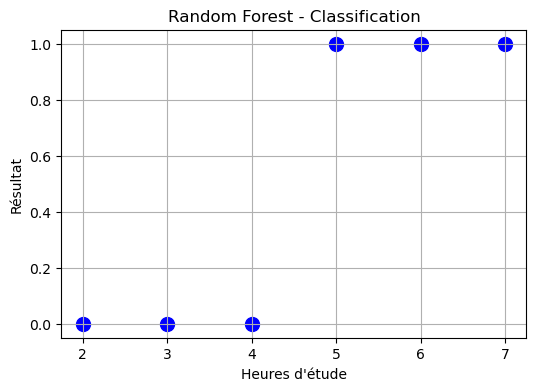

In [10]:
# RANDOM FOREST - Classification supervisée

import numpy as np
# Importation de la bibliothèque numpy.
# Cette bibliothèque est utilisée pour manipuler les données numériques
# sous forme de tableaux et de matrices.
# Elle est très importante en machine learning
# car elle permet d’effectuer des calculs rapides et optimisés.

import matplotlib.pyplot as plt
# Importation de matplotlib.
# Cette bibliothèque sert à créer des graphiques
# afin de visualiser les données et les résultats du modèle.

from sklearn.ensemble import RandomForestClassifier
# Importation du modèle Random Forest.
# Random Forest est un algorithme supervisé
# basé sur plusieurs arbres de décision.
# Chaque arbre effectue une prédiction,
# puis le modèle choisit la réponse finale
# grâce à un système de vote majoritaire.

from sklearn.model_selection import train_test_split
# Fonction permettant de séparer automatiquement le dataset :
# - une partie pour l’apprentissage
# - une partie pour le test
# Cela permet d’évaluer les performances du modèle
# sur des données qu’il n’a jamais vues.

from sklearn.metrics import accuracy_score
# Fonction utilisée pour calculer l’accuracy.
# L’accuracy mesure le pourcentage
# de bonnes prédictions du modèle.

# ================================
# 1. Création du dataset
# ================================

X = np.array([
    [2, 1],
    [3, 2],
    [4, 2],
    [5, 3],
    [6, 4],
    [7, 5]
])
# X représente les variables explicatives (features).
#
# Chaque ligne représente un étudiant.
#
# Colonne 1 :
# nombre d’heures d’étude.
#
# Colonne 2 :
# niveau de participation en classe.
#
# Ces informations vont être utilisées
# pour prédire la réussite ou l’échec.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible (target).
#
# 0 = étudiant en échec
# 1 = étudiant réussi
#
# Le modèle doit apprendre la relation
# entre les données X et les résultats y.

# ================================
# 2. Séparation des données
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# train_test_split divise automatiquement les données.
#
# X_train :
# données utilisées pour entraîner le modèle.
#
# X_test :
# données utilisées pour tester le modèle.
#
# y_train :
# réponses associées aux données d’apprentissage.
#
# y_test :
# vraies réponses utilisées pour l’évaluation.
#
# test_size=0.2 :
# 20% des données seront utilisées pour le test.
#
# random_state=42 :
# permet de garder toujours le même découpage
# afin d’obtenir des résultats reproductibles.

# ================================
# 3. Création du modèle
# ================================

model = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42
)
# Création du modèle Random Forest.
#
# n_estimators=10 :
# le modèle va créer 10 arbres de décision.
#
# Chaque arbre apprend une partie différente des données.
#
# Les prédictions des arbres seront combinées
# pour produire une décision plus fiable.
#
# max_depth=3 :
# profondeur maximale de chaque arbre.
#
# Cela évite que le modèle apprenne "par cœur"
# les données d’entraînement.
#
# random_state=42 :
# garantit des résultats identiques
# à chaque exécution du programme.

# ================================
# 4. Entraînement du modèle
# ================================

model.fit(X_train, y_train)
# Le modèle commence la phase d’apprentissage.
#
# Il analyse les données d’entrée X_train
# ainsi que les réponses correctes y_train.
#
# Ensuite il construit plusieurs arbres
# capables de prédire les classes.
#
# Le but est de minimiser les erreurs
# entre les prédictions et les vraies réponses.

# ================================
# 5. Prédictions
# ================================

predictions = model.predict(X_test)
# Le modèle utilise les données de test
# pour effectuer des prédictions.
#
# Il retourne ici :
# 0 ou 1 selon la classe prédite.

print("Prédictions :", predictions)
# Affichage des prédictions du modèle.

# ================================
# 6. Évaluation des performances
# ================================

accuracy = accuracy_score(y_test, predictions)
# Calcul de l’accuracy.
#
# Accuracy =
# nombre de bonnes prédictions
# divisé par le nombre total de prédictions.
#
# Plus cette valeur est proche de 1,
# plus le modèle est performant.

print("Accuracy :", accuracy)
# Affichage du score final du modèle.

# ================================
# 7. Visualisation graphique
# ================================

plt.figure(figsize=(6,4))
# Création d’un graphique.
#
# figsize définit la taille de la figure.

plt.scatter(X[:,0], y, color="blue", s=100)
# Affichage des données sous forme de points.
#
# X[:,0] :
# première variable → heures d’étude.
#
# y :
# résultat final (0 ou 1).
#
# color="blue" :
# couleur des points.
#
# s=100 :
# taille des points.

plt.xlabel("Heures d'étude")
# Nom de l’axe horizontal.

plt.ylabel("Résultat")
# Nom de l’axe vertical.

plt.title("Random Forest - Classification")
# Titre du graphique.

plt.grid(True)
# Ajout d’une grille
# pour rendre le graphique plus lisible.

plt.show()
# Affichage final du graphique.

Classe prédite : 1


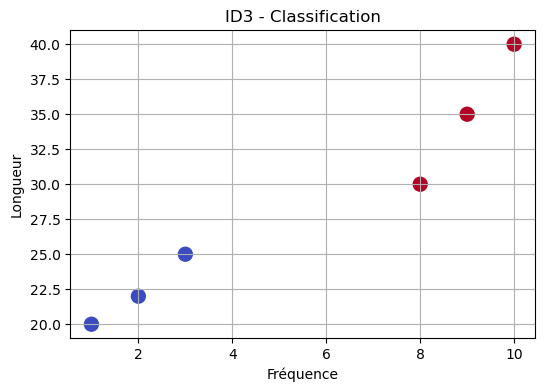

In [7]:
# ID3 - Arbre de décision


import numpy as np
# Importation de numpy.
# Cette bibliothèque permet de manipuler facilement
# les tableaux numériques et les matrices.

import matplotlib.pyplot as plt
# Importation de matplotlib.
# Cette bibliothèque sert à créer des graphiques
# pour visualiser les données.

from sklearn.tree import DecisionTreeClassifier
# Importation du modèle DecisionTreeClassifier.
# Ce modèle permet de créer un arbre de décision.
#
# Dans ce cas, nous allons utiliser ID3,
# qui est basé sur le calcul de l’entropie
# et du gain d’information.

# ================================
# 1. Création du dataset
# ================================

X = np.array([
    [1, 20],
    [2, 22],
    [3, 25],
    [8, 30],
    [9, 35],
    [10, 40]
])
# X représente les variables explicatives.
#
# Chaque ligne représente un message.
#
# Colonne 1 :
# fréquence de certains mots.
#
# Colonne 2 :
# longueur du message.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible.
#
# 0 = message normal
# 1 = message spam

# ================================
# 2. Création du modèle ID3
# ================================

model = DecisionTreeClassifier(criterion="entropy")
# Création du modèle ID3.
#
# criterion="entropy"
# indique que le modèle doit utiliser
# l’entropie et le gain d’information
# pour construire l’arbre.

# ================================
# 3. Entraînement
# ================================

model.fit(X, y)
# Le modèle analyse les données.
#
# Il cherche les meilleures règles
# permettant de séparer les classes.
#
# Chaque nœud de l’arbre correspond
# à une condition sur les variables.

# ================================
# 4. Prédiction
# ================================

prediction = model.predict([[9, 32]])
# Le modèle reçoit une nouvelle donnée :
#
# fréquence = 9
# longueur = 32
#
# Ensuite il décide
# si le message est spam ou non.

print("Classe prédite :", prediction[0])
# Affichage du résultat final.

# ================================
# 5. Graphe
# ================================

plt.figure(figsize=(6,4))
# Création de la figure.

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=100)
# Affichage des données.
#
# X[:,0] :
# fréquence des mots.
#
# X[:,1] :
# longueur du message.
#
# c=y :
# couleur selon la classe.
#
# cmap="coolwarm" :
# palette de couleurs.

plt.xlabel("Fréquence")
# Nom de l’axe X.

plt.ylabel("Longueur")
# Nom de l’axe Y.

plt.title("ID3 - Classification")
# Titre du graphique.

plt.grid(True)
# Ajout d’une grille.

plt.show()
# Affichage final.

Résultat prédit : 1


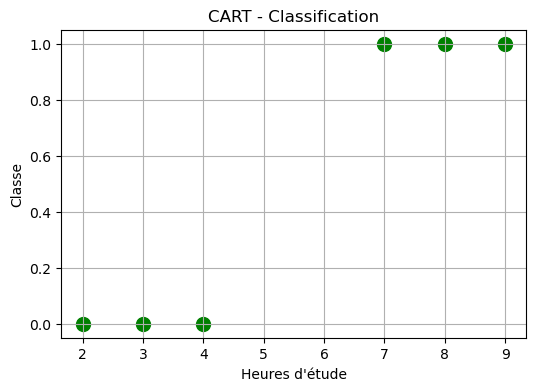

In [8]:
# CART - Arbre de décision

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
# Importation du modèle arbre de décision.
#
# CART utilise l’indice de Gini
# pour séparer les classes.

# ================================
# 1. Dataset
# ================================

X = np.array([
    [2],
    [3],
    [4],
    [7],
    [8],
    [9]
])
# Variable explicative :
# nombre d’heures d’étude.

y = np.array([0, 0, 0, 1, 1, 1])
# Variable cible :
#
# 0 = échec
# 1 = réussite

# ================================
# 2. Création du modèle CART
# ================================

model = DecisionTreeClassifier(criterion="gini")
# criterion="gini"
# signifie que le modèle utilise
# l’indice de Gini pour mesurer
# la qualité des séparations.

# ================================
# 3. Entraînement
# ================================

model.fit(X, y)
# Le modèle construit un arbre
# capable de séparer les étudiants
# selon leurs heures d’étude.

# ================================
# 4. Prédiction
# ================================

prediction = model.predict([[6]])
# Le modèle prédit le résultat
# pour un étudiant qui étudie 6 heures.

print("Résultat prédit :", prediction[0])

# ================================
# 5. Graphe
# ================================

plt.figure(figsize=(6,4))

plt.scatter(X, y, color="green", s=100)
# Affichage des données réelles.

plt.xlabel("Heures d'étude")
# Axe horizontal.

plt.ylabel("Classe")
# Axe vertical.

plt.title("CART - Classification")
# Titre du graphique.

plt.grid(True)

plt.show()

Classe prédite : 1


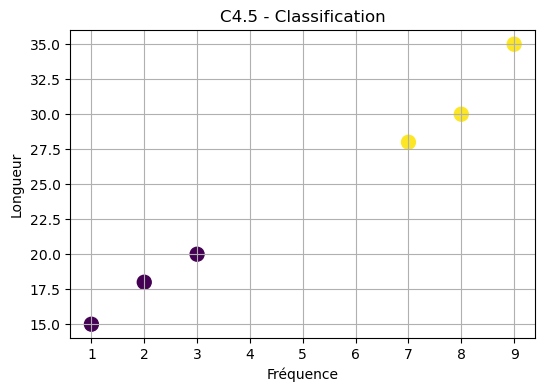

In [9]:
# ================================
# C4.5 - Arbre de décision
# ================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
# Importation du modèle arbre de décision.
#
# C4.5 est une amélioration de ID3.
# Il gère mieux les données complexes
# et réduit le surapprentissage.

# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 15],
    [2, 18],
    [3, 20],
    [7, 28],
    [8, 30],
    [9, 35]
])
# Variables explicatives :
#
# colonne 1 :
# fréquence des mots.
#
# colonne 2 :
# longueur du message.

y = np.array([0, 0, 0, 1, 1, 1])
# Variable cible :
#
# 0 = message normal
# 1 = spam

# ================================
# 2. Création du modèle
# ================================

model = DecisionTreeClassifier(criterion="entropy")
# Utilisation de l’entropie.
#
# C4.5 utilise aussi le gain d’information
# mais avec des améliorations supplémentaires.

# ================================
# 3. Entraînement
# ================================

model.fit(X, y)
# Le modèle apprend automatiquement
# à séparer les différentes classes.

# ================================
# 4. Prédiction
# ================================

prediction = model.predict([[8, 32]])
# Nouvelle donnée à classifier.

print("Classe prédite :", prediction[0])

# ================================
# 5. Graphe
# ================================

plt.figure(figsize=(6,4))

plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=100)
# Affichage des données.
#
# La couleur dépend de la classe.

plt.xlabel("Fréquence")
# Axe horizontal.

plt.ylabel("Longueur")
# Axe vertical.

plt.title("C4.5 - Classification")
# Titre du graphique.

plt.grid(True)

plt.show()